# DSAI 490 Assignment 1: Autoencoder and VAE

In [1]:
import os
import sys
import json

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.decomposition import PCA

sys.path.append('..')

from src.data_processing import load_dataset
from src.model import build_ae_encoder, build_ae_decoder, build_vae_encoder, build_vae_decoder

print('TensorFlow Version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('Detected GPUs:', gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

BATCH_SIZE = 64
LATENT_DIM = 32
DATA_DIR = '../data/raw/Medical MNIST'

train_dataset, class_names = load_dataset(DATA_DIR, BATCH_SIZE)
print('Found classes:', class_names)

sample_images, sample_labels = next(iter(train_dataset))
print('Sample batch shape:', sample_images.shape)

I0000 00:00:1777130708.195021   19470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777130709.484473   19470 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777130724.488393   19470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Version: 2.21.0
Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1777130738.499818   19470 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Sample batch shape: (64, 64, 64, 1)


In [2]:
ae_encoder = build_ae_encoder(latent_dim=LATENT_DIM)
ae_decoder = build_ae_decoder(latent_dim=LATENT_DIM)
vae_encoder = build_vae_encoder(latent_dim=LATENT_DIM)
vae_decoder = build_vae_decoder(latent_dim=LATENT_DIM)

ae_encoder.load_weights(os.path.join('..', 'models', 'ae_encoder.weights.h5'))
ae_decoder.load_weights(os.path.join('..', 'models', 'ae_decoder.weights.h5'))
vae_encoder.load_weights(os.path.join('..', 'models', 'vae_encoder.weights.h5'))
vae_decoder.load_weights(os.path.join('..', 'models', 'vae_decoder.weights.h5'))

print('Loaded saved model weights.')

Loaded saved model weights.


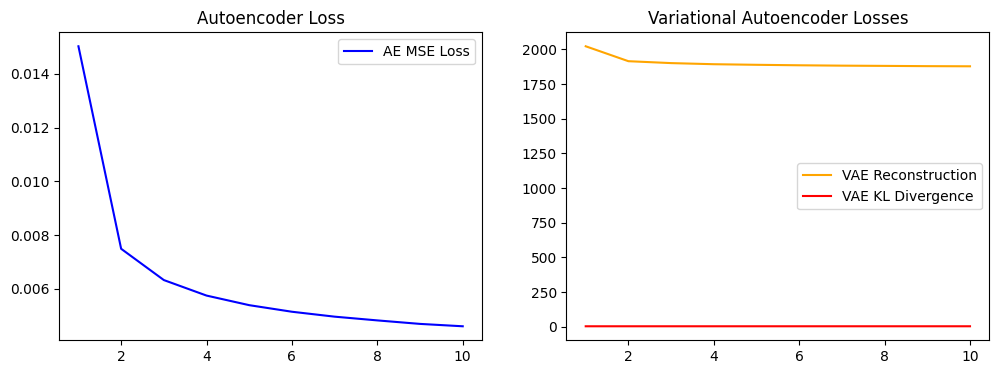

In [3]:
history_path = os.path.join('..', 'models', 'training_history.json')

if os.path.exists(history_path):
    with open(history_path, 'r', encoding='utf-8') as history_file:
        history = json.load(history_file)

    ae_loss_history = history.get('ae_loss_history', [])
    vae_recon_loss_history = history.get('vae_recon_loss_history', [])
    vae_kl_loss_history = history.get('vae_kl_loss_history', [])

    epochs_range = range(1, len(ae_loss_history) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, ae_loss_history, label='AE MSE Loss', color='blue')
    plt.title('Autoencoder Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, vae_recon_loss_history, label='VAE Reconstruction', color='orange')
    plt.plot(epochs_range, vae_kl_loss_history, label='VAE KL Divergence', color='red')
    plt.title('Variational Autoencoder Losses')
    plt.legend()
    plt.show()
else:
    print('training_history.json not found in ../models/. Run python -m src.train first.')

I0000 00:00:1777130756.315190   29879 service.cc:153] XLA service 0x72913402e150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777130756.315223   29879 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777130756.372299   29879 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777130756.459396   29879 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777130761.073305   29879 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1777130763.832936   29882 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_913__.1


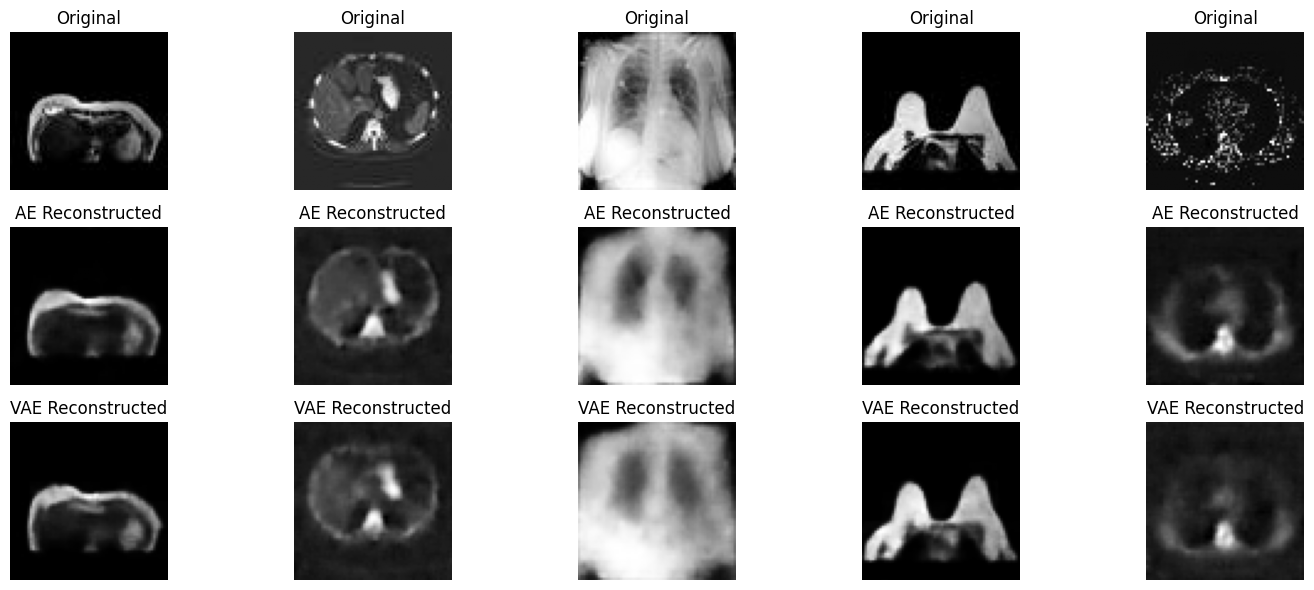

In [4]:
ae_recon = ae_decoder.predict(ae_encoder.predict(sample_images[:5], verbose=0), verbose=0)
_, _, vae_z = vae_encoder.predict(sample_images[:5], verbose=0)
vae_recon = vae_decoder.predict(vae_z, verbose=0)

plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(sample_images[i].numpy().squeeze(), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(3, 5, i + 6)
    plt.imshow(ae_recon[i].squeeze(), cmap='gray')
    plt.title('AE Reconstructed')
    plt.axis('off')

    plt.subplot(3, 5, i + 11)
    plt.imshow(vae_recon[i].squeeze(), cmap='gray')
    plt.title('VAE Reconstructed')
    plt.axis('off')

plt.tight_layout()
plt.show()

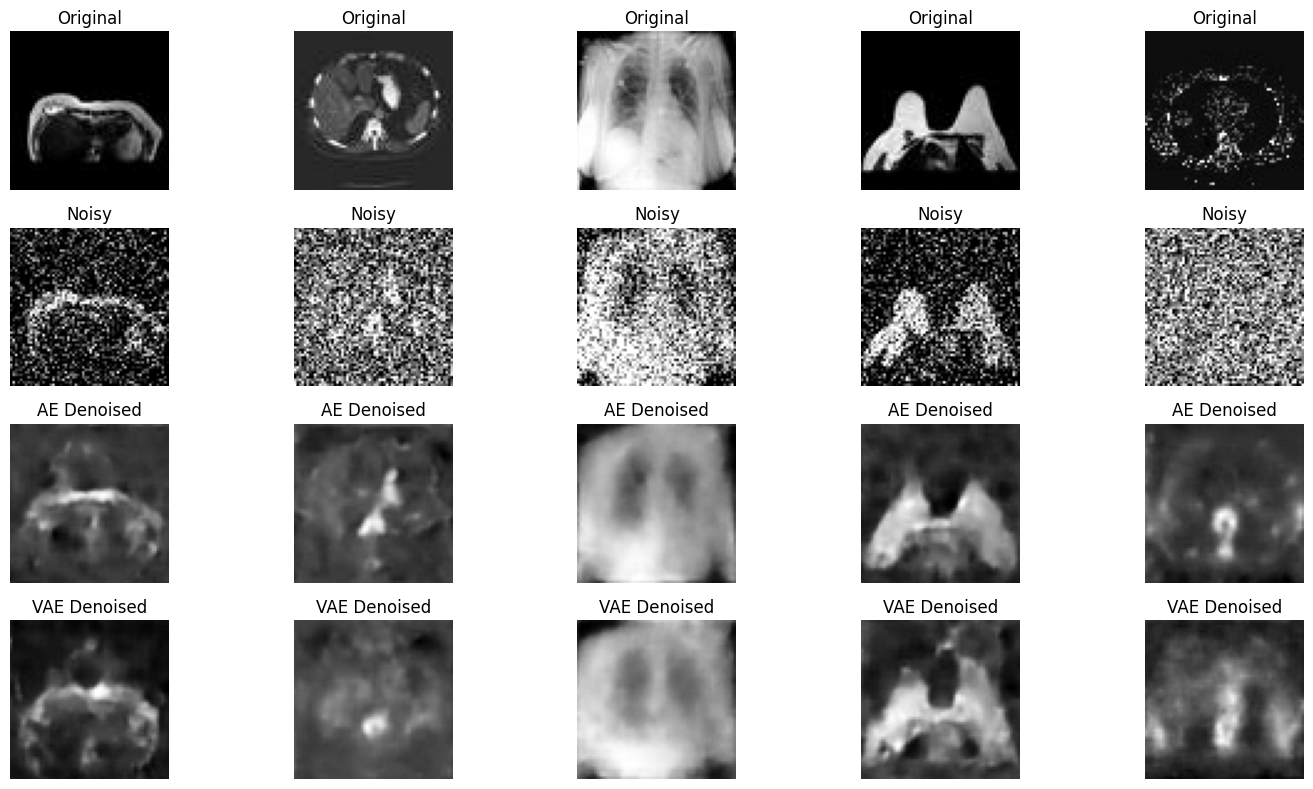

In [5]:
noise_factor = 0.35
clean_images = sample_images[:5]
noisy_images = tf.clip_by_value(
    clean_images + noise_factor * tf.random.normal(shape=tf.shape(clean_images)),
    0.0,
    1.0,
)

ae_denoised = ae_decoder.predict(ae_encoder.predict(noisy_images, verbose=0), verbose=0)
_, _, vae_z_noisy = vae_encoder.predict(noisy_images, verbose=0)
vae_denoised = vae_decoder.predict(vae_z_noisy, verbose=0)

plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(4, 5, i + 1)
    plt.imshow(clean_images[i].numpy().squeeze(), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(4, 5, i + 6)
    plt.imshow(noisy_images[i].numpy().squeeze(), cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    plt.subplot(4, 5, i + 11)
    plt.imshow(ae_denoised[i].squeeze(), cmap='gray')
    plt.title('AE Denoised')
    plt.axis('off')

    plt.subplot(4, 5, i + 16)
    plt.imshow(vae_denoised[i].squeeze(), cmap='gray')
    plt.title('VAE Denoised')
    plt.axis('off')

plt.tight_layout()
plt.show()

I0000 00:00:1777130769.558060   29882 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1482__.1


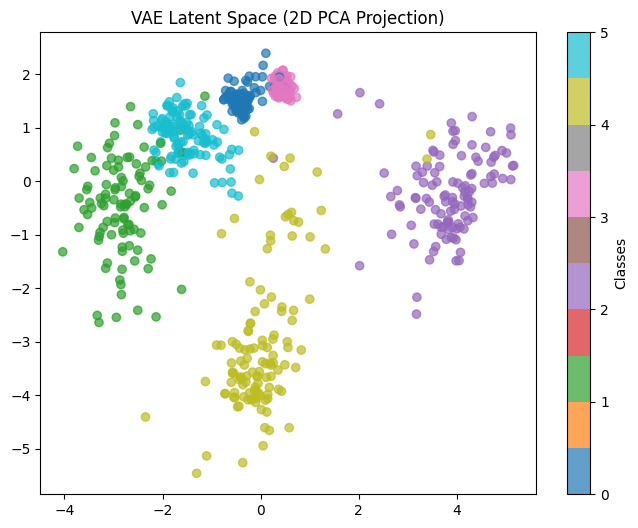

In [6]:
all_z = []
all_labels = []
for images, labels in train_dataset.take(10):
    _, _, z = vae_encoder.predict(images, verbose=0)
    all_z.append(z)
    all_labels.append(labels)

all_z = np.vstack(all_z)
all_labels = np.concatenate(all_labels)

pca = PCA(n_components=2)
z_2d = pca.fit_transform(all_z)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(len(class_names)), label='Classes')
plt.title('VAE Latent Space (2D PCA Projection)')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


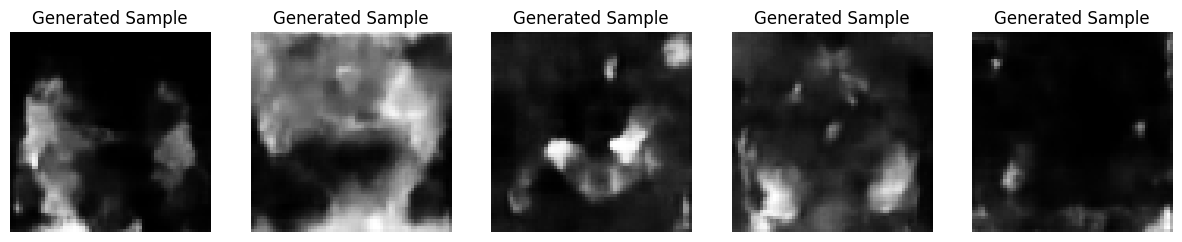

In [7]:
random_latent_vectors = tf.random.normal(shape=(5, LATENT_DIM))
generated_images = vae_decoder.predict(random_latent_vectors)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.title('Generated Sample')
    plt.axis('off')
plt.show()